# File Description
This file aims to verify the correctness of the Factorization Machine (FM).  
We first generate a random BQM (QUBO) and train an FM to learn the BQM. If the energies (ys) calculated from the BQM are close to the energies (ys_pred) predicted by the FM for a set of configurations (xs), we can conclude that the FM is correct.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Setting Environment Variable (Has to be set before importing mxnet, or it will perform multiprocessing automatically but without any imrpoved efficiency)
os.environ['MXNET_CPU_WORKER_NTHREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

# Factorization Machine
import mxnet as mx
from mxnet import nd
from factorization_machine import FactorizationMachine as OriginalFactorizationMachine

# BQM
import dimod

In [2]:
var_num = 16    # number of vars in bqm

# Generate a bqm

In [3]:
# Generate a bqm with weights in [-1, 1]

def custom_bias_generator(var_num):
    return np.random.uniform(-1, 1, var_num)

bqm = dimod.generators.gnm_random_bqm(
          variables = var_num,
          num_interactions = var_num*(var_num-1)/2,
          vartype = dimod.BINARY,
          bias_generator=custom_bias_generator
      )

In [4]:
b = bqm.offset       # bias     -> type: 0-D numpy
h = bqm.linear       # linear   -> type: dict like
Q = bqm.quadratic    # coupling -> type: dict like

In [5]:
# Convert the dict like data to ndarray
N = len(h)    # it should be identical to "var_num"
h_arr = np.array([h[i] for i in range(N)], np.float64)
Q_arr = np.zeros((N, N))
for (i, j), value in Q.items():
    Q_arr[i, j] = value
Q_arr = Q_arr + Q_arr.T
np.fill_diagonal(Q_arr, h_arr)    # fill the diagonal terms in Q_arr as the elements in h_arr

Text(0.5, 1.0, 'Q Matrix')

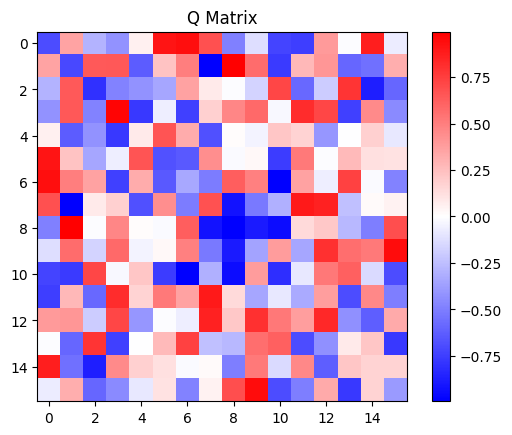

In [6]:
# Plot the Q matrix
max_abs_val = np.max(np.abs(Q_arr))
plt.figure()
plt.imshow(Q_arr, cmap="bwr", vmin=-max_abs_val, vmax=max_abs_val)
plt.colorbar()
plt.title("Q Matrix")

In [7]:
# Try using a smaller "var_num" and check if it gives the same energy as you calculated
config = np.random.randint(0, 2, var_num, np.int8)
energy = bqm.energy(config)
print(energy)

1.9736192629578517


# Test FM

In [8]:
class FactorizationMachine(OriginalFactorizationMachine):

    def __call__(self, xs):
        """Override __call__ to handle numpy array input automatically."""
        if isinstance(xs, np.ndarray):
            xs = nd.array(xs)  # 自動轉換 numpy 陣列
        return super().__call__(xs)
    
    def loss(self, dataset):
        """
        計算loss
        - mean((ys - outputs)**2)
    
        參數
        - dataset: [xs, ys]
        """
        xs = nd.array(dataset[0])
        ys = nd.array(dataset[1])
        return nd.mean( ( ys - self(xs) ) ** 2 ).asscalar()

    def get_bhQ_scaled(self):
        """原始程式有做scaling"""
        # b: bias, h: linear, Q: quadratic (上三角部分)，皆為 numpy array
        b, h, Q = self.get_bhQ()  
        
        h_max = np.max(np.abs(h))
        Q_max = np.max(np.abs(Q))
        scaling_factor = max(h_max, Q_max)
        
        b /= scaling_factor
        h /= scaling_factor
        Q /= scaling_factor

        return b, h, Q

    def bqm(self):
        """從 model 得到 bqm"""
        b, h, Q = self.get_bhQ()
        # b, h, Q = self.get_bhQ_scaled()    # b: bias, h: linear, Q: quadratic (上三角部分)，皆為 numpy array

        return dimod.BinaryQuadraticModel(h, Q, b, dimod.BINARY)    # BQM(linear, quadratic, offset, vartype)

    def plot_Q_matrix(self, show_fig=False, path_fig="Q_matrix_heatmap.png", save_fig=True, path_data="Q_matrix.npy", save_data=True):
        """畫Q matrix的heatmap"""
        b, h, Q = self.get_bhQ()
        # b, h, Q = self.get_bhQ_scaled()    # bias, linear, qudratic(upper tri)
        Q = Q + Q.T
        np.fill_diagonal(Q, h)
        
        if save_data:
            np.save(path_data, Q)

        if show_fig or save_fig:
            max_abs_val = np.max(np.abs(Q))
            plt.figure()
            plt.imshow(Q, cmap="bwr", vmin=-max_abs_val, vmax=max_abs_val)
            plt.colorbar()
            plt.title("Q Matrix")

            if save_fig:
                plt.savefig(path_fig, bbox_inches='tight', transparent=True)
            if show_fig:
                plt.show()
            else:
                plt.close()

    def save_model(self, path="model.params"):
        """儲存model參數、optimizer狀態"""
        mx.nd.waitall()
        self.save_parameters(path)
        
        if self.trainer is not None:
            self.trainer.save_states(path + ".trainer")

    @staticmethod
    def load_model(var_num, K, path="model.params"):
        """
        讀取並返回model參數、optimizer狀態

        參數
        - var_num : qubits數
        - K       : Factorization Machine的K
        """
        model = FactorizationMachine(input_size=var_num, factorization_size=K, act="identity")
        model.load_parameters(path, ctx=mx.cpu())

        # 需要先初始化 Trainer，然後才能載入 state
        model.trainer = mx.gluon.Trainer(model.collect_params(), "adam")

        try:
            model.trainer.load_states(path + ".trainer")
        except FileNotFoundError:
            print("沒有讀到optimizer的參數")

        return model

In [9]:
# Generate the training and testing dataset for FM
dataset_size = 10_000
xs = np.random.randint(0, 2, (dataset_size, var_num), np.int8)
ys = np.array([bqm.energy(x) for x in xs], np.float64)

In [10]:
# Initialize FM
K = var_num    # latent factor
model = FactorizationMachine(input_size=var_num, factorization_size=K, act="identity")
model.init_params(initializer=mx.init.Normal())

# Train FM
num_epoch = 5_000
learning_rate = 1e-2
model.train(xs, ys, num_epoch=num_epoch, learning_rate=learning_rate)

In [11]:
# Test FM
test_num = 50_000
xs = np.random.randint(0, 2, (test_num, var_num), np.int8)
ys = np.array([bqm.energy(x) for x in xs], np.float64)                 # label
ys_pred = np.array([model.bqm().energy(x) for x in xs], np.float64)    # predict from FM

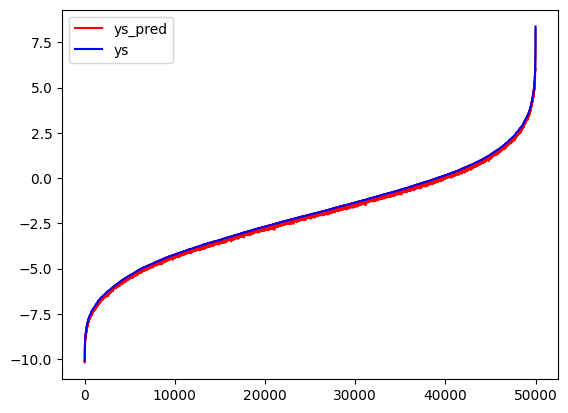

In [12]:
# Sort ascendingly based on ys
sorted_indices = np.argsort(ys)
ys = ys[sorted_indices]
ys_pred = ys_pred[sorted_indices]

# If the FM is correct and well-trained, these two line charts will have similar values
plt.plot(ys_pred, color="red", label="ys_pred")
plt.plot(ys, color="blue", label="ys")
plt.legend()
plt.show()